# Resort Guest Churn Prediction

This notebook walks through the full pipeline we built to predict which resort guests are likely to cancel.
One notebook covering the full pipeline end to end.

**The goal:** given what we know about a guest (age, booking type, spending, loyalty points, etc.),
predict whether they will churn (1) or stay (0).

**Metric:** F1 score (balances precision and recall, good for binary classification).

## 1. Setup & Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # quiet mode — only show errors

RANDOM_STATE = 42
TARGET = "Churned"
ID_COL = "GuestID"

# Column groups we'll reuse throughout the notebook.
CATEGORICALS = [
    "PromoCode", "Region", "AllInclusive", "PackageType", "VIP",
    "BookingChannel", "AgeGroup", "ReferralSource",
]
SPEND_COLS = ["RoomService", "Dining", "Retail", "Spa", "Entertainment"]
NUMERICS = ["Age"] + SPEND_COLS + ["LoyaltyPoints", "SurveyScore", "DaysSinceEmail"]

print("categoricals:", CATEGORICALS)
print("numerics    :", NUMERICS)

DATA_DIR = Path("data")

print("All imports OK")

categoricals: ['PromoCode', 'Region', 'AllInclusive', 'PackageType', 'VIP', 'BookingChannel', 'AgeGroup', 'ReferralSource']
numerics    : ['Age', 'RoomService', 'Dining', 'Retail', 'Spa', 'Entertainment', 'LoyaltyPoints', 'SurveyScore', 'DaysSinceEmail']
All imports OK


## 2. Load the Data

In [32]:
train = pd.read_csv(DATA_DIR / "resort_train.csv")
test  = pd.read_csv(DATA_DIR / "resort_test.csv")

print(f"Train: {train.shape[0]:,} rows  x  {train.shape[1]} columns")
print(f"Test:  {test.shape[0]:,} rows  x  {test.shape[1]} columns")
train.head()

Train: 6,954 rows  x  21 columns
Test:  1,739 rows  x  20 columns


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


## 3. EDA
1. Data quality (Missingness & Balance)
2. Univariate Churn Signal Analysis 
3. High spend cohort (audit)
4. Standalone vs Model-Based Predictive Signal 
5. Interaction Analysis
6. Room parsing (wing / floor / view, wing-relative floor) 
7. Train vs test distribution comparison: KS / PSI test 

### 3.1 Data Quality

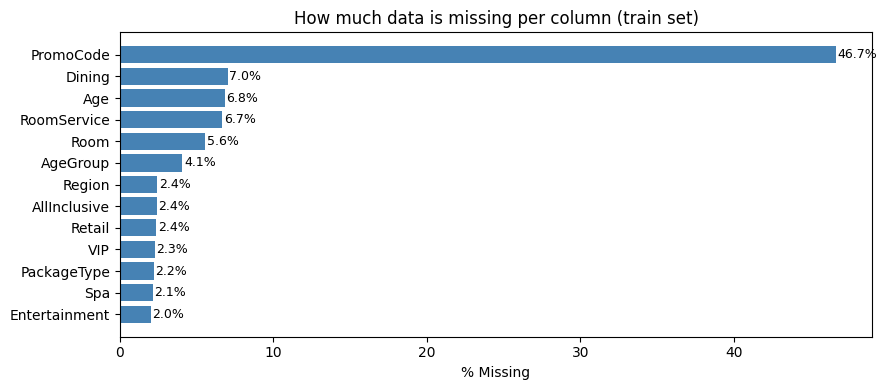

In [33]:
# Find the % of missing data per column 
missing_pct = (train.isna().sum() / len(train) * 100).sort_values()
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(missing_pct.index, missing_pct.values, color="steelblue")
ax.set_xlabel("% Missing")
ax.set_title("How much data is missing per column (train set)")
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Rows with 0 missing values : 2363
Rows with 1+ missing values: 4591
Max missing values in a row: 5


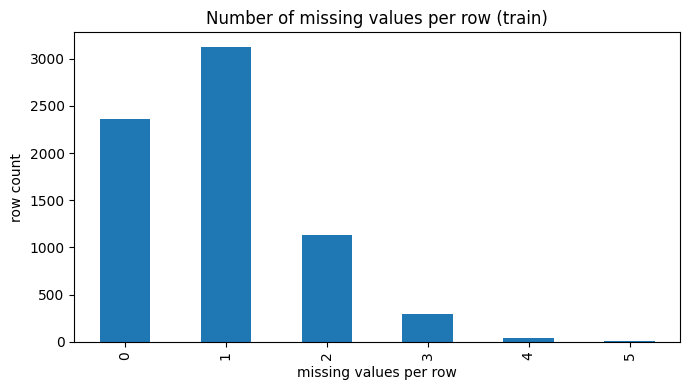

In [34]:
# Find the number of missing values per row 
missing_per_row = train.isna().sum(axis=1)

print(f"Rows with 0 missing values : {(missing_per_row == 0).sum()}")
print(f"Rows with 1+ missing values: {(missing_per_row >= 1).sum()}")
print(f"Max missing values in a row: {missing_per_row.max()}")

fig, ax = plt.subplots(figsize=(7, 4))
missing_per_row.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Number of missing values per row (train)")
ax.set_xlabel("missing values per row")
ax.set_ylabel("row count")
plt.tight_layout()
plt.show()


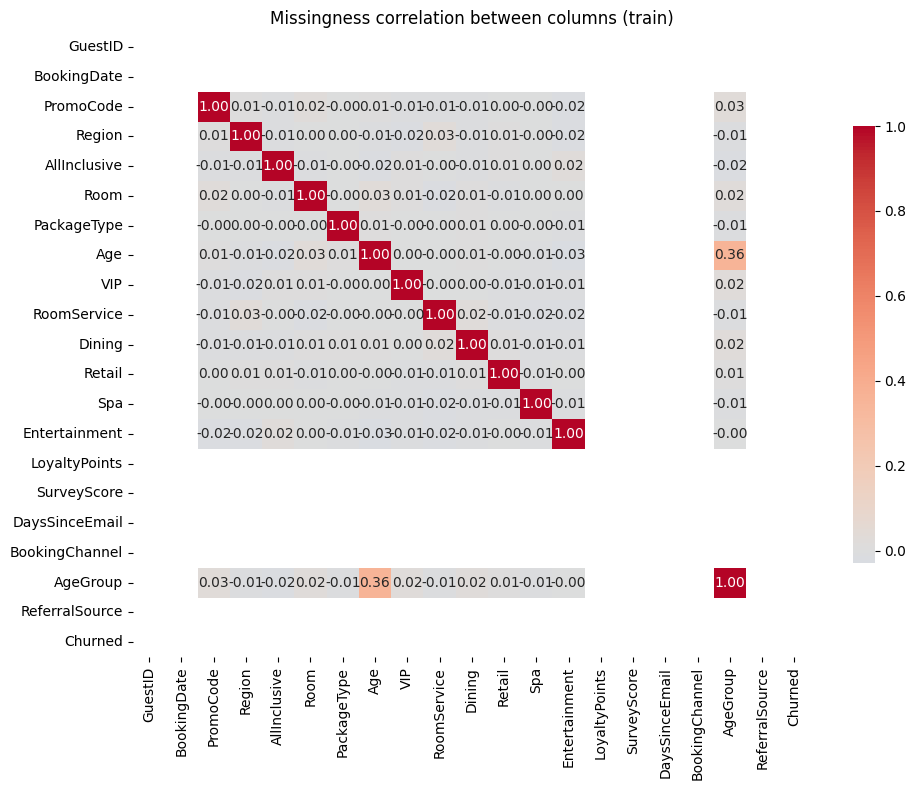

In [35]:
# 3.2 — do columns go missing together? (Pearson correlation of NaN indicators using seaborn heatmap and matplotlib)
miss_corr = train.isna().corr().round(2)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(miss_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Missingness correlation between columns (train)")
plt.tight_layout()
plt.show()

# Findings: missingness is not correlated with each other
# but age and age group does have a positive correlation of 0.36 which is expected

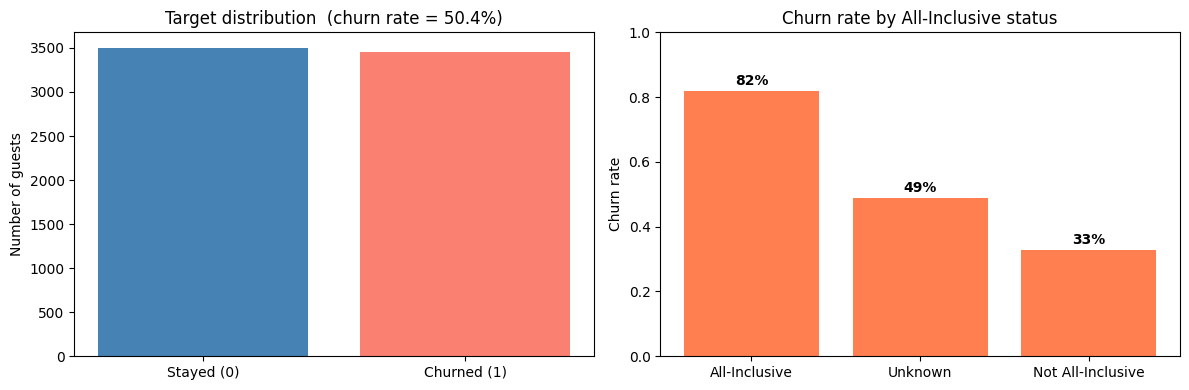

In [36]:
# --- Target balance ---
# How many guests actually churned vs stayed?
churn_counts = train[TARGET].value_counts()
churn_rate = train[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw counts
axes[0].bar(["Stayed (0)", "Churned (1)"], churn_counts.values, color=["steelblue", "salmon"])
axes[0].set_title(f"Target distribution  (churn rate = {churn_rate:.1%})")
axes[0].set_ylabel("Number of guests")

# Right: churn rate by All-Inclusive package
# This is one of the strongest signals in the data
ai_labels = {0.0: "Not All-Inclusive", 1.0: "All-Inclusive"}
ai_churn = (
    train.assign(AI=train["AllInclusive"].map(ai_labels).fillna("Unknown"))
    .groupby("AI")[TARGET].mean()
    .sort_values(ascending=False)
)
axes[1].bar(ai_churn.index, ai_churn.values, color="coral")
axes[1].set_ylabel("Churn rate")
axes[1].set_ylim(0, 1)
axes[1].set_title("Churn rate by All-Inclusive status")
for i, v in enumerate(ai_churn.values):
    axes[1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [37]:
# Is missingness itself predictive of churn?
results = []
# loop through all columns in the train set
for col in train.columns:
    # skip the target column
    if col == TARGET:
        continue
    # check if the column has missing values
    is_missing = train[col].isna()
    # if the column has no missing values, skip
    if is_missing.sum() == 0:
        continue
    # calculate the churn rate when the column has missing values as a dictionary so its easy to convert to a dataframe
    results.append({
        "column": col,
        # check the number of missing values in the column
        "n_missing": int(is_missing.sum()),
        # calculate the churn rate when the column has missing values
        # Show me only the rows where this column is missing, then look at the churn column & calculate the average.
        "churn_when_missing": train.loc[is_missing, TARGET].mean(),
        # calculate the churn rate when the column has no missing values
        "churn_when_present": train.loc[~is_missing, TARGET].mean(),
    })

miss_target = pd.DataFrame(results)
miss_target["delta"] = (miss_target["churn_when_missing"] - miss_target["churn_when_present"]).round(3)
miss_target.sort_values("delta", ascending=False)

# Findings: Finding: columns with a large delta suggest that missingness itself may be predictive of churn 
# Feature Engineering (FE): worth investigate PromoCode, Room, AgeGroup

,column,n_missing,churn_when_missing,churn_when_present,delta
0,PromoCode,3245,0.669337,0.358587,0.311
3,Room,386,0.676166,0.493453,0.183
12,AgeGroup,283,0.657244,0.497077,0.160
10,Spa,148,0.547297,0.502645,0.045
8,Dining,488,0.526639,0.501856,0.025
7,RoomService,464,0.510776,0.503082,0.008
4,PackageType,153,0.509804,0.503455,0.006
5,Age,476,0.506303,0.503396,0.003
9,Retail,164,0.506098,0.503535,0.003
11,Entertainment,139,0.503597,0.503595,0.000


### 3.2 Univariate Churn Signal Analysis
Goal: segment guests by one feature at a time and compare churn rates across those groups

#### 2.1 Univariate churn rates - Categoricals 

In [38]:
# Base rate: overall churn rate in the dataset
# Lift: churn rate vs base rate
# Share: proportion of rows in each category relative to the whole dataset
# Delta: churn rate - base rate

base_rate = train[TARGET].mean()

for col in CATEGORICALS:
    table = train.groupby(col, dropna=False).agg(
        count=(TARGET, "size"),
        churn_rate=(TARGET, "mean"),
    )
    table["share"] = (table["count"] / table["count"].sum()).round(3)
    table["lift_vs_base"] = (table["churn_rate"] - base_rate).round(3)
    table = table.sort_values("churn_rate", ascending=False).round(3)
    print(f"\n--- {col} ---")
    print(table)

# Findings: 
# 1. AllInclusive=True: 82% churn 
# 2. PromoCode=NaN: ~ 67% churn → NaN here is meaningful, need to be treated as None, no fill needed.
# 3. Region=Europe ~ 66% vs. Americas ~ 43% → churn differs sharply by region (Europe reads as riskier in this slice than Americas on this one variable alone).
# 4. VIP=True: ~ 37% meaning VIP is associated with lower churn (~37%) than typical non‑VIP base rates → implies loyalty program working but not proof VIP *causes* retention.



--- PromoCode ---
           count  churn_rate  share  lift_vs_base
PromoCode                                        
NaN         3245       0.669  0.467         0.166
PromoB      1884       0.360  0.271        -0.144
PromoA      1825       0.357  0.262        -0.146

--- Region ---
             count  churn_rate  share  lift_vs_base
Region                                             
Europe        1692       0.662  0.243         0.158
AsiaPacific   1420       0.520  0.204         0.016
NaN            169       0.491  0.024        -0.012
Americas      3673       0.425  0.528        -0.079

--- AllInclusive ---
              count  churn_rate  share  lift_vs_base
AllInclusive                                        
1.0            2436       0.819  0.350         0.315
NaN             168       0.488  0.024        -0.015
0.0            4350       0.328  0.626        -0.176

--- PackageType ---
             count  churn_rate  share  lift_vs_base
PackageType                                

#### 2.2 Univariate churn rates - Binned Numeric 

In [39]:
for col in ["Age", "LoyaltyPoints", "DaysSinceEmail"]:
    # use deciles to bin the data
    bins = pd.qcut(train[col], q=10, duplicates="drop")
    # group the data by the bins and calculate the count and churn rate
    table = train.groupby(bins, observed=True).agg(
        count=(TARGET, "size"),
        churn_rate=(TARGET, "mean"),
    ).round(3)
    # print the results 
    print(f"\n--- {col} (deciles) ---")
    print(table)

print("\n--- SurveyScore ---")
print(train.groupby("SurveyScore")[TARGET].agg(count="size", churn_rate="mean").round(3))

# Findings:
# 1. LoyaltyPoints (deciles): churn is roughly flat across buckets (here about 48%–53%). Almost no steady more points → more/less churn pattern alone.
# 2. SurveyScore: roughly balanced counts across scores 1–5, and churn sits near the ~50% for each (range is ~49%–52%)
# 3. Age: 0–13 has the highest churn rate: 66.7%, After age 18, the churn rate mostly stays around 45% to 51%. 
# 4. DaysSinceEmail: churn by decile ranging from ~47%–53% →  mostly flat, limited evidence that guests with longer gaps since email interaction are more likely to churn.


--- Age (deciles) ---
                count  churn_rate
Age                              
(-0.001, 13.0]    738       0.667
(13.0, 18.0]      705       0.533
(18.0, 21.0]      677       0.449
(21.0, 24.0]      702       0.453
(24.0, 27.0]      589       0.491
(27.0, 30.0]      495       0.511
(30.0, 35.0]      663       0.466
(35.0, 41.0]      703       0.465
(41.0, 49.0]      591       0.496
(49.0, 79.0]      615       0.488

--- LoyaltyPoints (deciles) ---
                  count  churn_rate
LoyaltyPoints                      
(-0.001, 1038.6]    696       0.480
(1038.6, 2064.2]    695       0.502
(2064.2, 3069.0]    697       0.494
(3069.0, 4076.0]    695       0.524
(4076.0, 5055.5]    694       0.506
(5055.5, 6046.8]    695       0.486
(6046.8, 7030.0]    697       0.518
(7030.0, 7984.6]    694       0.494
(7984.6, 9008.5]    695       0.504
(9008.5, 9996.0]    696       0.529

--- DaysSinceEmail (deciles) ---
                count  churn_rate
DaysSinceEmail                   
(-

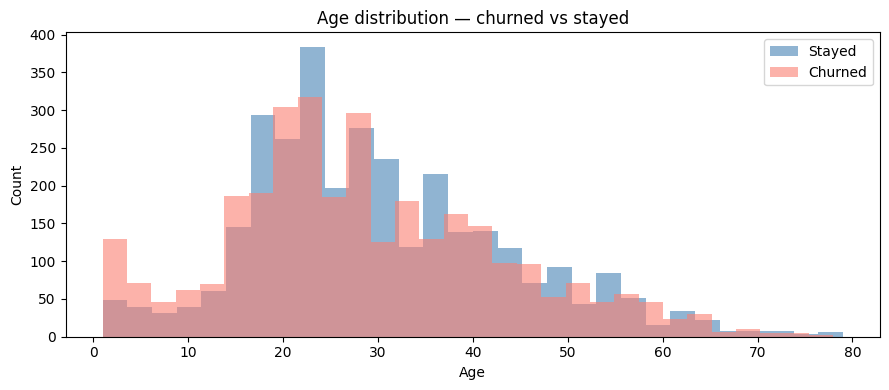

In [40]:
# Age distribution by churn
# Note: Age == 0 in the raw data is actually a data error (missing age), so we filter those out here.
age_data = train[train["Age"] > 0].dropna(subset=["Age"])

fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [(0, "steelblue"), (1, "salmon")]:
    subset = age_data[age_data[TARGET] == label]["Age"]
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f"{'Churned' if label else 'Stayed'}")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.set_title("Age distribution — churned vs stayed")
ax.legend()
plt.tight_layout()
plt.show()

#### 2.3 Univariate churn rates - Numeric Spend 
Spend Cols has a huge spike at $0 -> use manual bins.

In [41]:
# split the spend columns into bins manually
spend_bins = [-1, 0, 100, 1000, 10_000, 100_000, np.inf]
spend_labels = ["= 0", "(0,100]", "(100,1k]", "(1k,10k]", "(10k,100k]", "> 100k"]

for col in SPEND_COLS:
    bucket = pd.cut(train[col], bins=spend_bins, labels=spend_labels)
    table = train.groupby(bucket, observed=True).agg(
        count=(TARGET, "size"),
        churn_rate=(TARGET, "mean"),
    ).round(3)
    print(f"\n--- {col} ---")
    print(table)

# Findings: Guests with 0 spend consistently had the highest churn rates, around 59% to 64%
# Guests with moderate service usage generally had much lower churn rates



--- RoomService ---
             count  churn_rate
RoomService                   
= 0           4145       0.632
(0,100]        765       0.370
(100,1k]       978       0.237
(1k,10k]       469       0.130
(10k,100k]      19       0.579
> 100k         114       0.526

--- Dining ---
            count  churn_rate
Dining                       
= 0          4102       0.587
(0,100]       759       0.216
(100,1k]      835       0.309
(1k,10k]      603       0.542
(10k,100k]     38       0.737
> 100k        129       0.457

--- Retail ---
            count  churn_rate
Retail                       
= 0          4420       0.600
(0,100]       916       0.223
(100,1k]     1012       0.314
(1k,10k]      303       0.568
(10k,100k]      3       0.333
> 100k        136       0.544

--- Spa ---
            count  churn_rate
Spa                          
= 0          4208       0.636
(0,100]       955       0.383
(100,1k]     1037       0.247
(1k,10k]      457       0.116
(10k,100k]     18       0.

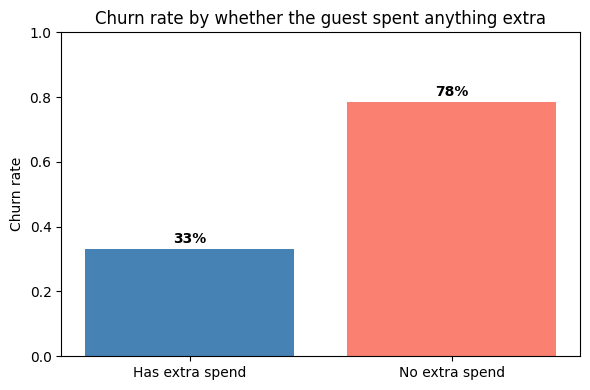

In [42]:
# Does extra spending predict churn? 
# Findings: Guests who spent on things like dining or spa behave differently from those who didn't touch anything.
total_spend = train[SPEND_COLS].sum(axis=1)
has_spend = (total_spend > 0).map({True: "Has extra spend", False: "No extra spend"})
spend_churn = train.groupby(has_spend)[TARGET].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(spend_churn.index, spend_churn.values, color=["steelblue", "salmon"])
ax.set_ylabel("Churn rate")
ax.set_ylim(0, 1)
ax.set_title("Churn rate by whether the guest spent anything extra")
for i, v in enumerate(spend_churn.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 High-spend cohort profile 
Goal : audit rows with any spend > $100K. Are these data errors or a real subpopulation?

In [43]:
# checks whether each guest has more than $100K spend in any spend category, then returns True/False.
is_high = (train[SPEND_COLS].fillna(0) > 100_000).any(axis=1)

# prints the number of rows in the train dataset that have more than $100K spend in any spend category and the percentage. 
print(f"High-spend rows (>$100k in any category): {int(is_high.sum())}  ({is_high.mean()*100:.1f}% of train)")
# Among guests where is_high == True, take their churn values and calculate the average.
print(f"Their churn rate          : {train.loc[is_high, TARGET].mean():.3f}")

# Among guests where is_high == False, take their churn values and calculate the average.
# Everyone else = guests with no individual spend category above $100K
print(f"Everyone else's churn rate: {train.loc[~is_high, TARGET].mean():.3f}")

# How many spend categories are >$100k for these rows? Mostly 1, hopefully not all 5.
# For guests who already spent over $100K in at least one category,
# count how many spend categories are over $100K for each guest.
n_extreme_categories = (train.loc[is_high, SPEND_COLS].fillna(0) > 100_000).sum(axis=1)
print("\nNumber of spend categories >$100k per row:")
print(n_extreme_categories.value_counts().sort_index())

# Findings:
# 1. High-spend rows (>$100k in any category): 635  (9.1% of train) & isn't a data error. 
# FE: High-spend guests appear to be a distinct segment → create an extreme high-spend feature.


High-spend rows (>$100k in any category): 635  (9.1% of train)
Their churn rate          : 0.523
Everyone else's churn rate: 0.502

Number of spend categories >$100k per row:
1    614
2     20
3      1
Name: count, dtype: int64


### 3.4 Standalone vs Model-Based Predictive Signal 
Goal: 
Find features with high split count but lower gain -> could be simplified into cleaner buckets or grouped categories. 
Features that appear weak alone but useful in LightGBM -> candidates for interaction features.


#### 3.4.1 Mutual Info Ranking 
How much does knowing this feature reduce uncertainty about churn? -> A higher mutual information score means the feature may contain more useful signal for predicting churn.

In [44]:
from sklearn.feature_selection import mutual_info_classif
# drop the id, booking date and room columns because they are not useful for the model
df = train.copy().drop(columns=[ID_COL, "BookingDate", "Room"])

# Track which columns are categorical (we'll mark them as discrete for the MI estimator).
object_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in object_cols:
    # fill the missing values with "__NA__", treat column as categories and .cat.codes converts category labels into numbers.
    df[col] = df[col].fillna("__NA__").astype("category").cat.codes
    
# Boolean-ish columns AllInclusive / VIP are also discrete.
discrete_set = set(object_cols + ["AllInclusive", "VIP", "SurveyScore"])
# fill the missing values with -1 because MI estimator doesn't accept NaN
df = df.fillna(-1)

# X contains all the input features, except the churn target
X = df.drop(columns=[TARGET])
# y contains only the target column, which is churn.
y = df[TARGET]
# Create a True/False list showing which feature columns should be treated as discrete by the mutual information function.
discrete_mask = np.array([c in discrete_set for c in X.columns])
# calculate the mutual information between the features and the target
mi_values = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=RANDOM_STATE) # random_state is used to make the results reproducible
# convert the mutual information values to a pandas series and sort them in descending order
mi = pd.Series(mi_values, index=X.columns).sort_values(ascending=False)

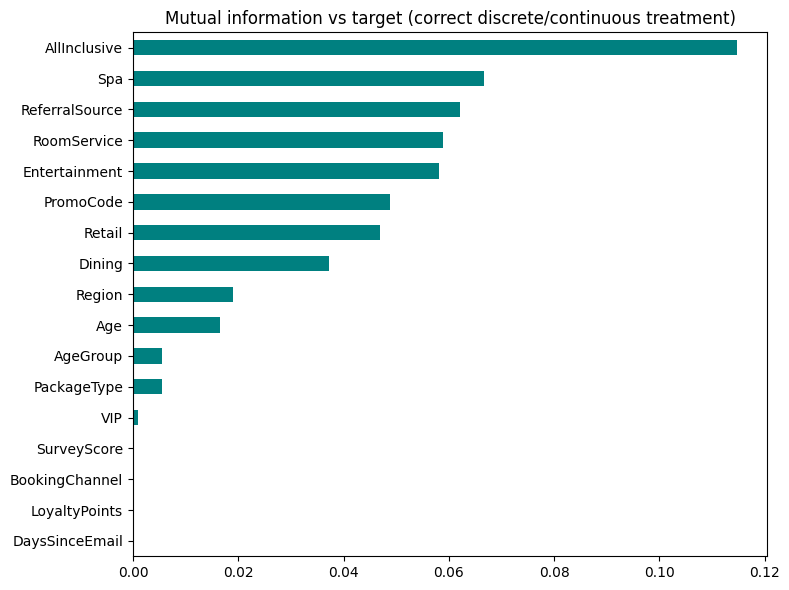

AllInclusive      0.1148
Spa               0.0667
ReferralSource    0.0621
RoomService       0.0589
Entertainment     0.0581
PromoCode         0.0489
Retail            0.0470
Dining            0.0372
Region            0.0191
Age               0.0165
AgeGroup          0.0056
PackageType       0.0055
VIP               0.0009
SurveyScore       0.0002
BookingChannel    0.0000
LoyaltyPoints     0.0000
DaysSinceEmail    0.0000
dtype: float64

In [45]:
# plot the mutual information vs target
fig, ax = plt.subplots(figsize=(8, 6))
mi.plot(kind="barh", ax=ax, color="teal")
ax.invert_yaxis()
ax.set_title("Mutual information vs target (correct discrete/continuous treatment)")
plt.tight_layout()
plt.show()

mi.round(4)

# Findings: AllInclusive has the strongest individual relationship with churn among the features tested.

#### 3.4.2 LightGBM feature-importance baseline (tree-based boosting)
Steps:
1. Label-encode categoricals just for this model (LGBM accepts that natively).
2. Fit a quick 200-tree LightGBM with default settings — no tuning, just signal.
3. Plot gain importance + split count importance side by side.

In [46]:
from lightgbm import LGBMClassifier

# copy of the train to df 
# drop the id and booking date columns because they are not useful for the model
df = train.copy().drop(columns=[ID_COL, "BookingDate"])

# Parse Room & split into Wing / Floor / View so LGBM can use them.
# expand=True is used to split the string into multiple columns
rooms_split = df["Room"].str.split("/", expand=True)
# slice into the dataframe and assign the first column to Wing
df["Wing"] = rooms_split[0]
# convert the second column to a numeric value and assign it to Floor
df["Floor"] = pd.to_numeric(rooms_split[1], errors="coerce")
# assign the third column to View
df["View"] = rooms_split[2]
# drop the Room column from the dataframe
df = df.drop(columns=["Room"])

# LGBM can handle pandas 'category' dtype natively.
# loop through the columns & select columns that are of type object or string 
for c in df.select_dtypes(include=["object", "string"]).columns:
    # fill the missing values with "__NA__" and convert the column to a category
    df[c] = df[c].fillna("__NA__").astype("category")

# convert the target column to an integer (make sure the target column is integer), this is our label
y = df[TARGET].astype(int)
# drop the target column from X, this is the features we use to train our model
X = df.drop(columns=[TARGET])

lgbm = LGBMClassifier(
    # n_estimators is the number of trees in the model (we'll use 200 trees as it's the industry standard for testing)
    n_estimators=200, 
    # learning_rate is the step size shrinkage used to prevent overfitting
    # It takes the correction suggested by each new tree and only applies 5% of that correction to the overall model.
    learning_rate=0.05, 
    # num_leaves is the maximum number of leaves in one tree
    # gives the model enough flexibility to learn churn patterns without letting each tree become too complex. 
    num_leaves=31,
    # random_state is the seed used by the random number generator
    random_state=RANDOM_STATE, 
    verbose=-1,
)
# fit the model to the data to learn patterns in X that predict churn y.
lgbm.fit(X, y)

# calculate the feature importance for the model

# Gain = how much a feature improved the model when it was used.
fi_gain = pd.Series(lgbm.booster_.feature_importance(importance_type="gain"),
                     index=X.columns, name="gain")
# Split = how often the feature was used
fi_split = pd.Series(lgbm.booster_.feature_importance(importance_type="split"),
                     index=X.columns, name="split")

# creates a table showing which features with both gain and split columns.
fi = pd.concat([fi_gain, fi_split], axis=1).sort_values("gain", ascending=False)

fi

# how to interpret the split: Across all 200 trees, LightGBM used ReferralSource 315 times to split the data.

,gain,split
AllInclusive,17576.623216,124
ReferralSource,6058.945025,315
PromoCode,5442.275824,195
Entertainment,4968.268968,589
Spa,4930.380683,579
Floor,4746.774684,768
Dining,4184.334497,525
RoomService,3875.039349,466
Age,3486.121542,570
Wing,2675.878770,160


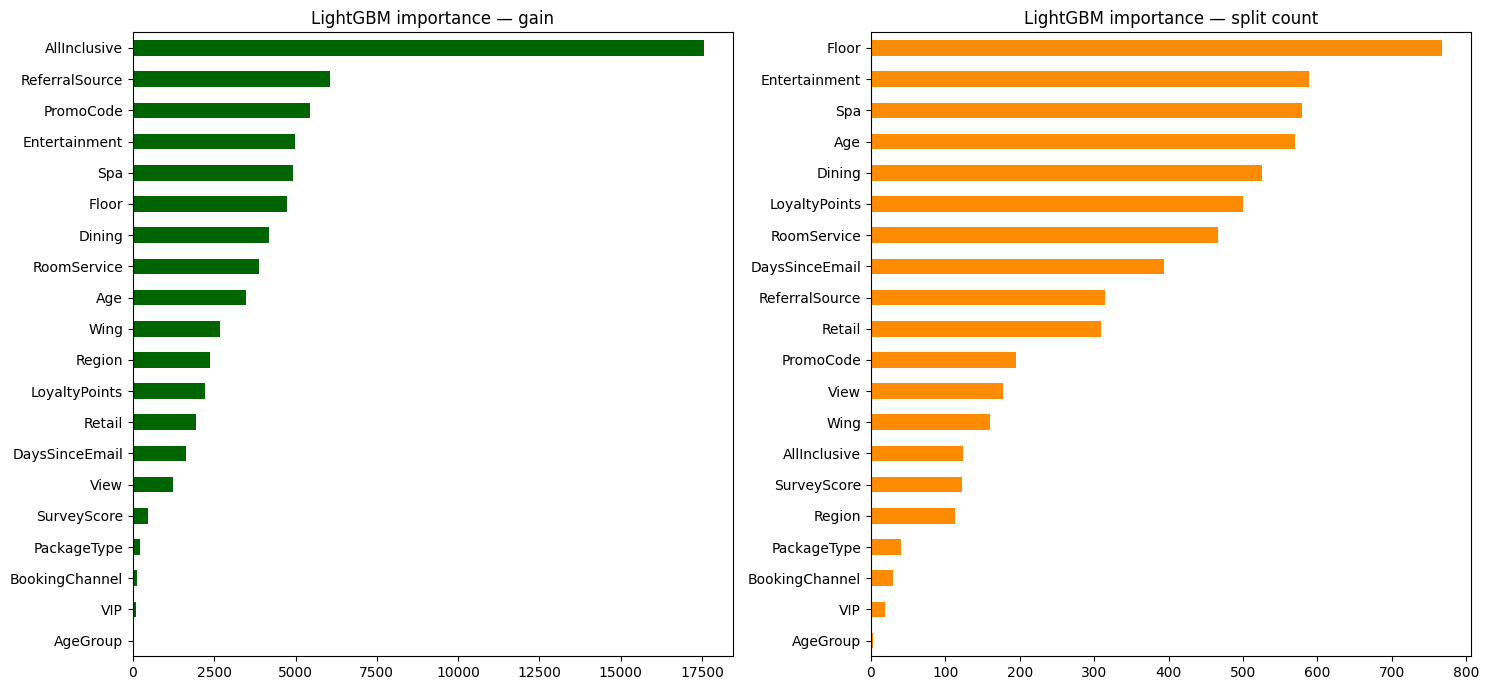

In [47]:
# plot the feature importance for the model 
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fi["gain"].sort_values().plot(kind="barh", ax=axes[0], color="darkgreen")
axes[0].set_title("LightGBM importance — gain")
fi["split"].sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("LightGBM importance — split count")
plt.tight_layout()
plt.show()

# gain = how much a feature improved the model when used in splits (Every time LightGBM splits on a feature, it reduces prediction error a bit & gain adds up all those improvements.)
# split count is how often boosting revisits it across trees.

# Findings: 
# 1. All-inclusive status, acquisition/promotion signals (ReferralSource, PromoCode),and amenity engagement (Entertainment, Spa, Dining, RoomService, Retail)
# are the strong churn-risk indicators.
# 2. High split-count features with lower gain, such as Floor, may be useful for segmentation but may not be strong standalone drivers. 
# These features can be simplified during feature engineering (e.g., we can engineer broader buckets such as low_floor, mid_floor, and high_floor) 


### 3.5 Interaction Analysis

#### 3.5.1 AllInclusive x HasAnySpend

Q: Does churn differ depending on whether the guest is all-inclusive and whether they spent anything on resort services?

In [48]:
# fill NA with 0
total_spend = train[SPEND_COLS].fillna(0).sum(axis=1) # axis = 1 is row-wise
spent_something = total_spend > 0
is_ai = train["AllInclusive"] == 1

# .map is a pandas method that maps values to new values based on a dictionary
segments = pd.DataFrame({
    "AllInclusive": is_ai.map({True: "True", False: "False"}),
    "HasAnySpend": spent_something.map({True: "yes", False: "no"}),
    TARGET: train[TARGET],
})
segments

,AllInclusive,HasAnySpend,Churned
0,False,no,1
1,True,no,1
2,False,yes,0
3,True,no,1
4,False,yes,0
...,...,...,...
6949,False,yes,1
6950,False,yes,0
6951,False,yes,1
6952,True,no,1


In [49]:
 # group by AllInclusive and HasAnySpend and aggregate the churn rate
summary = segments.groupby(["AllInclusive", "HasAnySpend"]).agg(
    n=(TARGET, "size"),
    churn_rate=(TARGET, "mean"),
).round(3)
summary

n  churn_rate
AllInclusive HasAnySpend                  
False        no            466       0.622
             yes          4052       0.301
True         no           2191       0.819
             yes           245       0.816

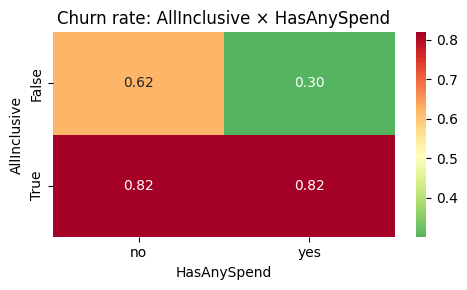

In [50]:
# Heatmap view
pivot = segments.groupby(["AllInclusive", "HasAnySpend"])[TARGET].mean().unstack()

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=train[TARGET].mean(), ax=ax)
ax.set_title("Churn rate: AllInclusive × HasAnySpend")
plt.tight_layout()
plt.show()

# Findings: 
# 1. 1. All-inclusive guests: high churn rates, around 82%, regardless of whether they had additional spend. 
# 2. Non-all-inclusive guests, having any resort spend is associated with lower churn: 30.1% versus 62.2%.

# FE: 
# 1. HasAnySpend is a strong engineered feature within non-AllInclusive, HasAnySpend=no churns @ ~60% vs ~30% for HasAnySpend=yes


#### 3.5.2 Systematic Interaction Search: Feature × Feature 
Q: Are there combinations of two features where churn is unusually high or low, beyond what we would expect from each feature individually?
Goal: compute the joint churn rate for every pair of (low-cardinality categorical, low-cardinality categorical) & rank pairs by how far the joint churn rate deviates from what the marginals

In [51]:
pairs_cats = ["PromoCode", "Region", "AllInclusive", "PackageType", "VIP", "BookingChannel", "AgeGroup"]

interaction_rows = []
base_rate = train[TARGET].mean()
# This is a nested loop that iterates over all pairs of categories in pairs_cats
# # Loop through each categorical feature and pair it only with the features after it,
# so each feature pair is tested once and duplicates like A×B and B×A are avoided.

# Outer loop: choose the first feature.
# enumerate gives both the index,i and the feature name, a.
for i, a in enumerate(pairs_cats):
    #Inner loop: choose the second feature,only from features after a to avoid duplicate pairs
    for b in pairs_cats[i + 1:]:
        #Loop through each pair of values in the two features, with va = value of feature a
        # vb = value of feature b
        for va, vb in train.groupby([a, b]).groups.keys():
            #Create a mask for rows where the value of feature a matches va
            mask_a = train[a] == va
            #Create a mask for rows where the value of feature b matches vb
            mask_b = train[b] == vb
            #Create a joint mask for rows where both feature a and feature b match their respective values
            joint_mask = mask_a & mask_b
            #If the joint mask has less than 30 rows, skip this pair of values to protects the analysis from noisy tiny segments.
            if joint_mask.sum() < 30:
                continue
            #Calculate the joint churn rate for the joint mask
            joint_churn = train.loc[joint_mask, TARGET].mean()
            #Calculate the marginal churn rate for feature a
            marginal_a = train.loc[mask_a, TARGET].mean()
            marginal_b = train.loc[mask_b, TARGET].mean()
            interaction_rows.append({
                "a": f"{a}={va}",
                "b": f"{b}={vb}",
                "n": int(joint_mask.sum()),
                "joint_churn": round(joint_churn, 3),
                "marginal_a": round(marginal_a, 3),
                "marginal_b": round(marginal_b, 3),
                "lift_vs_base": round(joint_churn - base_rate, 3),
            })

interactions = pd.DataFrame(interaction_rows)
print("Top 15 pairs with highest |joint churn - base rate|:")
interactions.reindex(interactions["lift_vs_base"].abs().sort_values(ascending=False).index).head(15)

# Findings: 
# 1. Region=Europe × AllInclusive=1.0 is the highest-risk segment: 98.6% churn across 722 guests, which is 48.3% above the base churn rate.
# 2. AllInclusive=1.0 × PackageType=Adventure: 92.3% churn
# Region=AsiaPacific × AllInclusive=1.0: 91.5% churn. Region=Europe × AgeGroup=Minor: 87.3% churn

# FE: Create interaction features around AllInclusive, because most high-risk segments involve AllInclusive=1.0. 
# Prioritize only the strongest and most interpretable pairs (AllInclusive × Region, AllInclusive × AgeGroup)


Top 15 pairs with highest |joint churn - base rate|:


,a,b,n,joint_churn,marginal_a,marginal_b,lift_vs_base
45,Region=Europe,AllInclusive=1.0,722,0.986,0.662,0.819,0.483
92,AllInclusive=1.0,PackageType=Adventure,600,0.923,0.819,0.603,0.420
43,Region=AsiaPacific,AllInclusive=1.0,528,0.915,0.520,0.819,0.411
86,Region=Europe,AgeGroup=Minor,157,0.873,0.662,0.581,0.369
113,AllInclusive=1.0,AgeGroup=Elderly,58,0.862,0.819,0.477,0.358
56,Region=AsiaPacific,VIP=1.0,54,0.148,0.520,0.371,-0.355
114,AllInclusive=1.0,AgeGroup=Middle,586,0.845,0.819,0.474,0.341
116,AllInclusive=1.0,AgeGroup=Senior,236,0.831,0.819,0.484,0.327
106,AllInclusive=1.0,BookingChannel=TravelAgent,488,0.830,0.819,0.513,0.326
117,AllInclusive=1.0,AgeGroup=Young,807,0.823,0.819,0.474,0.319


In [52]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare the data for clustering

# 1. Filter out Age==0 sentinel rows.
df = train[train["Age"] != 0].copy()
print(f"Rows used for clustering: {len(df)} (dropped {(train['Age']==0).sum()} Age==0 rows)")

# 2. Numeric block — prepare numeric features: log1p spend (Apply log transform to spend columns.), fill remaining NaN with median, standardize.
num_cols = ["Age", "LoyaltyPoints", "SurveyScore", "DaysSinceEmail"] + SPEND_COLS
X_num = df[num_cols].copy()
for c in SPEND_COLS:
    # # For spend columns, treat missing spend as 0 before log-transforming; assumption: missing spend means no recorded spend in that category.
    # log1p compresses very large spend values so extreme spenders do not dominate the clustering.
    X_num[c] = np.log1p(X_num[c].fillna(0))
# Fill remaining NaN with median    
X_num = X_num.fillna(X_num.median())

# Standardize the numeric features
# fit = learn the mean and standard deviation of each column
# transform = use those values to scale the data
X_num_scaled = StandardScaler().fit_transform(X_num)

# 3. Categorical block — fill NaN as 'unknown', one-hot encode.
cat_cols = ["AllInclusive", "Region", "PackageType", "VIP", "PromoCode"]
# creates a categorical-only DataFrame, fill NaN with "unknown", converts all category values into strings so they are treated as labels not numbers.
X_cat = df[cat_cols].fillna("unknown").astype(str)
# one-hot encode the categorical features
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_encoded = ohe.fit_transform(X_cat)
# Create a one-hot encoder to convert categorical columns into 0/1 features.
# sparse_output=False returns a normal array.
# handle_unknown="ignore" prevents errors if unseen categories appear later.


# Stack numeric + categorical into one feature matrix.
X_full = np.hstack([X_num_scaled, X_cat_encoded])
print(f"Feature matrix shape: {X_full.shape}")

# 26 bc some categorical columns are expanded into multiple one-hot columns.

Rows used for clustering: 6816 (dropped 138 Age==0 rows)
Feature matrix shape: (6816, 26)


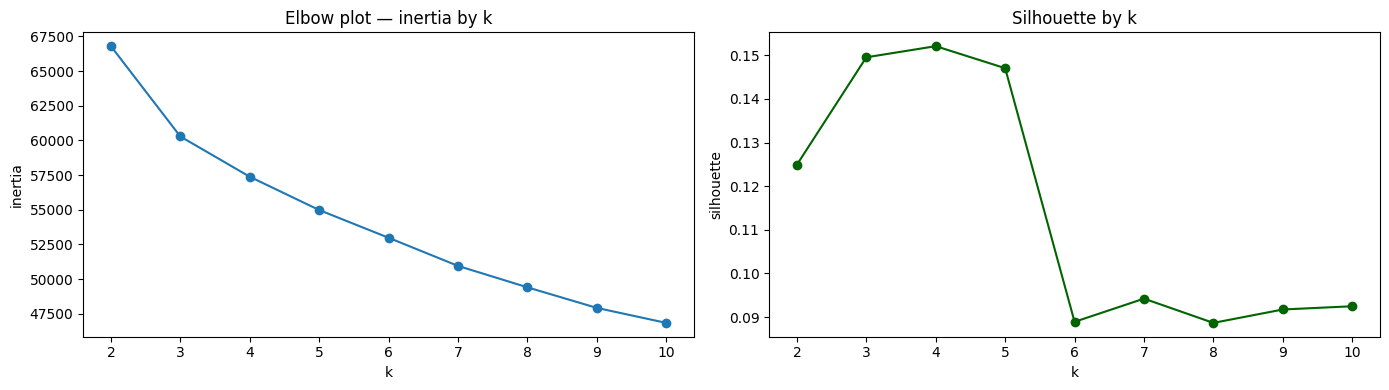


Best k by silhouette: 4


In [54]:
# 4. Scan k and pick by silhouette.

# inertia (Elbow Method) = total within-cluster squared distance; lower means clusters are more compact (always decreases as k increases)
# silhouette = cluster separation score; higher means points are closer to their own cluster
# than to the nearest other cluster
# squaring makes large distances much more expensive.

inertias = []
silhouettes = []
# test different cluster counts from 2 to 10, 
# then choose the best one based on silhouette score and the elbow plot.
# The “elbow” is the point where adding more clusters stops giving a big improvement.
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_full)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_full, labels, sample_size=2000, random_state=RANDOM_STATE))

# Elbow plot & silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow plot — inertia by k"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="darkgreen")
axes[1].set_title("Silhouette by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

# Best k by highest silhouette score
k_best = list(k_range)[int(np.argmax(silhouettes))]
print(f"\nBest k by silhouette: {k_best}")


In [55]:
# 5. Fit the chosen k - Try 10 different random initializations and choose the clustering solution with the lowest inertia.
# This is to ensure that the clustering solution is not sensitive to the initial random assignments.
kmeans_final = KMeans(n_clusters=k_best, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_full)

# 6. Persona table: size, churn rate, modal categorical levels, numeric means.
persona_rows = []
# Loop through every unique cluster ID in sorted order.
for cid in sorted(df["cluster"].unique()):
    # Create a new DataFrame containing only the rows where the cluster equals the current cluster ID.
    sub = df[df["cluster"] == cid]
    row = {
        "cluster": cid,
        "n": len(sub),
        "churn_rate": round(sub[TARGET].mean(), 3),
        "avg_age": round(sub["Age"].mean(), 1),
        "avg_loyalty": round(sub["LoyaltyPoints"].mean(), 0),
        "avg_total_spend": round(sub[SPEND_COLS].fillna(0).sum(axis=1).mean(), 0),
    }
    # Loop through each categorical feature.
    for c in cat_cols:
        # Fill NaN with "unknown" and count the occurrences of each category.
        vc = sub[c].fillna("unknown").value_counts(normalize=True)
        # Get the most frequent category and its percentage.
        row[f"top_{c}"] = f"{vc.index[0]} ({vc.iloc[0]*100:.0f}%)"
    # Append the row to the list of persona rows.
    persona_rows.append(row)

personas = pd.DataFrame(persona_rows).set_index("cluster")
personas


,n,churn_rate,avg_age,avg_loyalty,avg_total_spend,top_AllInclusive,top_Region,top_PackageType,top_VIP,top_PromoCode
cluster,,,,,,,,,,
0,1794,0.342,32.9,5057.0,63235.0,0.0 (90%),Americas (49%),Relaxation (65%),0.0 (94%),unknown (40%)
1,2633,0.763,26.0,5054.0,150.0,1.0 (81%),Americas (48%),Relaxation (63%),0.0 (97%),unknown (54%)
2,1356,0.211,31.4,4979.0,29059.0,0.0 (94%),Americas (52%),Relaxation (76%),0.0 (94%),unknown (39%)
3,1033,0.465,28.6,5064.0,42148.0,0.0 (93%),Americas (70%),Relaxation (72%),0.0 (96%),unknown (48%)


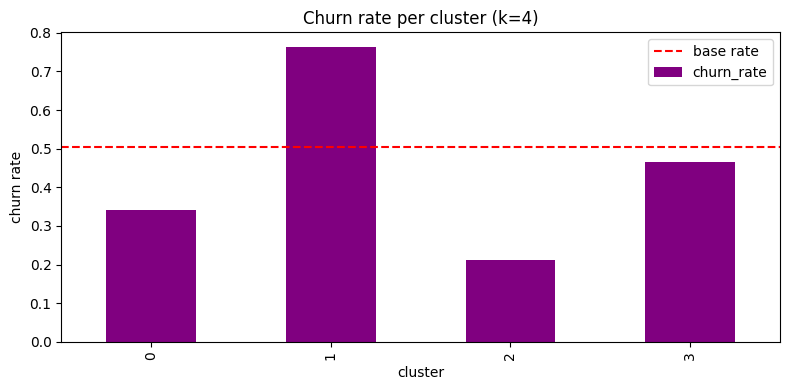

In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
personas["churn_rate"].plot(kind="bar", ax=ax, color="purple")
ax.axhline(train[TARGET].mean(), color="red", linestyle="--", label="base rate")
ax.set_title(f"Churn rate per cluster (k={k_best})")
ax.set_ylabel("churn rate")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Data Cleaning

A few issues need to be fixed before we can model. We apply the same rules to train and test
by combining them, cleaning once, then splitting back — this guarantees they're treated identically.

In [ ]:
# Combine train + test so cleaning rules fire exactly the same way on both
train["__split"] = "train"
test["__split"] = "test"
test[TARGET] = np.nan
full = pd.concat([train, test], ignore_index=True)

# PromoCode: NaN just means "no promo was used" — give it a label so the model sees it
full["PromoCode"] = full["PromoCode"].fillna("None")

# Age == 0 is a data entry error (138 guests recorded as age 0).
# We replace with NaN so CatBoost handles them as truly missing.
full.loc[full["Age"] == 0, "Age"] = np.nan

# AllInclusive has a NaN group that actually churns at a different rate than True or False.
# Keeping it as "unknown" lets the model treat it as its own category.
full["AllInclusive"] = (
    full["AllInclusive"]
    .map({0: "False", 1: "True", 0.0: "False", 1.0: "True"})
    .fillna("unknown")
)

# For the other text columns, missing means the data wasn't captured.
# "Unknown" is more informative than a blank and keeps the missingness signal alive.
for col in ["Region", "PackageType", "BookingChannel", "ReferralSource", "AgeGroup"]:
    full[col] = full[col].fillna("Unknown")

# Parse booking date so we can extract the month later
full["BookingDate"] = pd.to_datetime(full["BookingDate"], errors="coerce")

print(f"Combined shape: {full.shape}")
print(f"No Age==0 rows left: {(full['Age'] == 0).sum()}")
print(f"AllInclusive levels: {full['AllInclusive'].unique()}")

Combined shape: (8693, 22)
No Age==0 rows left: 0
AllInclusive levels: <ArrowStringArray>
['False', 'True', 'unknown']
Length: 3, dtype: str


## 5. Feature Engineering

The raw columns don't tell the full story. We build ~10 new features that the EDA told us are meaningful.

In [ ]:
# Spend features
# Whether a guest spent anything at all is a stronger signal than the spend amount itself.
full["Total_Spend"] = full[SPEND_COLS].sum(axis=1, skipna=True)
full["HasAnySpend"] = (full["Total_Spend"] > 0).astype(int)

# The single biggest interaction in the data 
# Europe + All-Inclusive guests churn at ~99%. This concatenated feature lets the 
# model split on that combination directly rather than needing two separate splits.
full["AllInclusive_Region"] = full["AllInclusive"] + "_" + full["Region"]

# Room features
# Room codes look like "G/1483/S" — that's wing / floor number / view type.
room_parts = full["Room"].str.split("/", expand=True)
full["Wing"] = room_parts[0].fillna("Unknown")
full["View"] = room_parts[2].fillna("Unknown")
full["Floor"] = pd.to_numeric(room_parts[1], errors="coerce")

# Raw floor number is meaningless across wings (wing A goes up to floor 107,
# wing F goes up to 1893). We normalize it within each wing so it's on a 0-1 scale.
wing_max = full.groupby("Wing")["Floor"].transform("max")
full["Floor_relative"] = full["Floor"] / wing_max

# Missingness flags
# Guests with missing Age or Room have noticeably higher churn rates,
# so we want the model to know when that data is absent.
full["Age_was_missing"] = full["Age"].isna().astype(int)
full["Room_was_missing"] = full["Room"].isna().astype(int)

# Date features - extract the month from the booking date
full["Booking_Month"] = full["BookingDate"].dt.month

# Engagement
# A quick composite: high survey score + recent email engagement = engaged guest.
# Subtract DaysSinceEmail so stale contacts pull the score down.
full["Engagement_Score"] = full["SurveyScore"] * 100 - full["DaysSinceEmail"]

print("Feature engineering done.")
print(f"Columns now: {full.shape[1]}")

Feature engineering done.
Columns now: 33


In [ ]:
# Split back into train and test
clean_train = full[full["__split"] == "train"].drop(columns=["__split"]).reset_index(drop=True)
clean_test  = full[full["__split"] == "test"].drop(columns=["__split", TARGET]).reset_index(drop=True)

# Define which columns go into the model
CAT_FEATURES = [
    "Region", "PackageType", "BookingChannel", "ReferralSource",
    "PromoCode", "AllInclusive", "Wing", "View", "AgeGroup", "AllInclusive_Region"
]
NUM_FEATURES = [
    "Age", "LoyaltyPoints", "SurveyScore", "DaysSinceEmail", "VIP",
    "RoomService", "Dining", "Retail", "Spa", "Entertainment",
    "Total_Spend", "HasAnySpend", "Floor_relative",
    "Age_was_missing", "Room_was_missing", "Booking_Month", "Engagement_Score"
]
FEATURE_COLS = NUM_FEATURES + CAT_FEATURES

# CatBoost needs categorical columns to be strings
X = clean_train[FEATURE_COLS].copy()
y = clean_train[TARGET].astype(int)
X_test = clean_test[FEATURE_COLS].copy()

for col in CAT_FEATURES:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print(f"Feature matrix: {X.shape}")
print(f"Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}")

Feature matrix: (6954, 27)
Categorical features (10): ['Region', 'PackageType', 'BookingChannel', 'ReferralSource', 'PromoCode', 'AllInclusive', 'Wing', 'View', 'AgeGroup', 'AllInclusive_Region']


## 6. Train a Baseline Model

We use CatBoost — it handles categorical features and missing values natively, which saves a lot of preprocessing.

5-fold cross-validation means we train 5 models, each on 80% of the data and evaluated on the remaining 20%.
The average F1 across those 5 folds is our reliable estimate of how well the model generalises.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Fill missing numeric values with median
X_Knn = X.fillna(X.median(numeric_only=True))

# Fill missing categorical values
for col in X_Knn.select_dtypes(include="object").columns:
    X_Knn[col] = X_Knn[col].fillna("Missing")

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X_Knn, drop_first=True)

# Scale features for KNN
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=X_encoded.columns,
    index=X_encoded.index
)

# Cross-validation setup
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

baseline_fold_scores = []

# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y)):

    X_tr = X_scaled.iloc[train_idx]
    X_val = X_scaled.iloc[val_idx]

    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # KNN model
    model = KNeighborsClassifier(
        n_neighbors=5
    )

    # Train model
    model.fit(X_tr, y_tr)

    # Predict
    preds = model.predict(X_val)

    # Evaluate
    score = f1_score(y_val, preds)

    baseline_fold_scores.append(score)

    print(f"Fold {fold + 1}: F1 = {score:.4f}")

# Average CV score
baseline_f1 = np.mean(baseline_fold_scores)

print(f"\nBaseline CV F1: {baseline_f1:.4f}")

Fold 1: F1 = 0.6890
Fold 2: F1 = 0.7254
Fold 3: F1 = 0.7202
Fold 4: F1 = 0.7247
Fold 5: F1 = 0.7036

Baseline CV F1: 0.7126


/var/folders/8h/c0qfdst9705dzbpf8qjp36sc0000gn/T/ipykernel_13349/2784892444.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_Knn.select_dtypes(include="object").columns:


In [ ]:
import xgboost as xgb

# Convert string/object columns to categorical (Native categorical handling ONLY works on pandas category dtype)
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_fold_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,

        # Native categorical support
        enable_categorical=True,
        tree_method="hist"
    )

    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)

    score = f1_score(y_val, preds)

    baseline_fold_scores.append(score)

    print(f"Fold {fold + 1}: F1 = {score:.4f}")

baseline_f1 = np.mean(baseline_fold_scores)

print(f"\nBaseline CV F1: {baseline_f1:.4f}")

/var/folders/8h/c0qfdst9705dzbpf8qjp36sc0000gn/T/ipykernel_13349/3567138081.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


Fold 1: F1 = 0.8240
Fold 2: F1 = 0.8397
Fold 3: F1 = 0.8348
Fold 4: F1 = 0.8190
Fold 5: F1 = 0.8220

Baseline CV F1: 0.8279


## 7. Hyperparameter Tuning with Optuna

The default CatBoost settings are already solid, but we can squeeze out a bit more performance
by searching over a few key settings. We use Optuna to run 25 trials automatically and pick the best.

We only tune 3 parameters to keep things fast and readable:
- `depth` — how deep each decision tree can grow
- `learning_rate` — how big each correction step is
- `iterations` — how many trees to build

In [ ]:
# Bayesian optimization -> Based on what I’ve already seen, what should I try next?

def objective(trial):
    params = {
        "depth":         trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "iterations":    trial.suggest_int("iterations", 100, 600),
        "random_seed":   RANDOM_STATE,
        "verbose":       0,
        "cat_features":  CAT_FEATURES,
        "thread_count":  -1,
    }

    # Use 3-fold inside Optuna to keep each trial fast
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in inner_cv.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        m = CatBoostClassifier(**params)
        m.fit(X_tr, y_tr)
        scores.append(f1_score(y_val, m.predict(X_val)))

    return np.mean(scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest 3-fold F1 from Optuna: {study.best_value:.4f}")
print(f"Baseline 5-fold F1 was:     {baseline_f1:.4f}")

  0%|          | 0/25 [00:00<?, ?it/s]

[W 2026-05-19 15:25:52,758] Trial 19 failed with parameters: {'depth': 7, 'learning_rate': 0.06372146911323631, 'iterations': 527} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/Users/diephan/MMAI869_Resortv1/resort_v1/.venv/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/8h/c0qfdst9705dzbpf8qjp36sc0000gn/T/ipykernel_13349/418105159.py", line 21, in objective
    m.fit(X_tr, y_tr)
    ~~~~~^^^^^^^^^^^^
  File "/Users/diephan/MMAI869_Resortv1/resort_v1/.venv/lib/python3.13/site-packages/catboost/core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              eval_set, verbose, loggi

KeyboardInterrupt: 

## 8. Evaluate

We train the tuned model on 80% of the training data and evaluate it on the held-out 20%.
This gives us concrete charts showing where the model is right and wrong.

In [ ]:
# Hold out 20% of train for evaluation charts
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

eval_model = CatBoostClassifier(
    # Use the best hyperparameters found by Optuna
    **study.best_params,
    random_seed=RANDOM_STATE,
    verbose=0,
    cat_features=CAT_FEATURES,
    thread_count=-1
)
eval_model.fit(X_tr, y_tr)

# Predict on the validation set
preds = eval_model.predict(X_val)
# Predict the probability of churn for each guest
# [:1,1] means the probability of churn (second column)
probs = eval_model.predict_proba(X_val)[:, 1]

# Calculate F1 score
val_f1 = f1_score(y_val, preds)
print(f"Validation F1 (tuned, 80/20 split): {val_f1:.4f}")

Validation F1 (tuned, 80/20 split): 0.8238


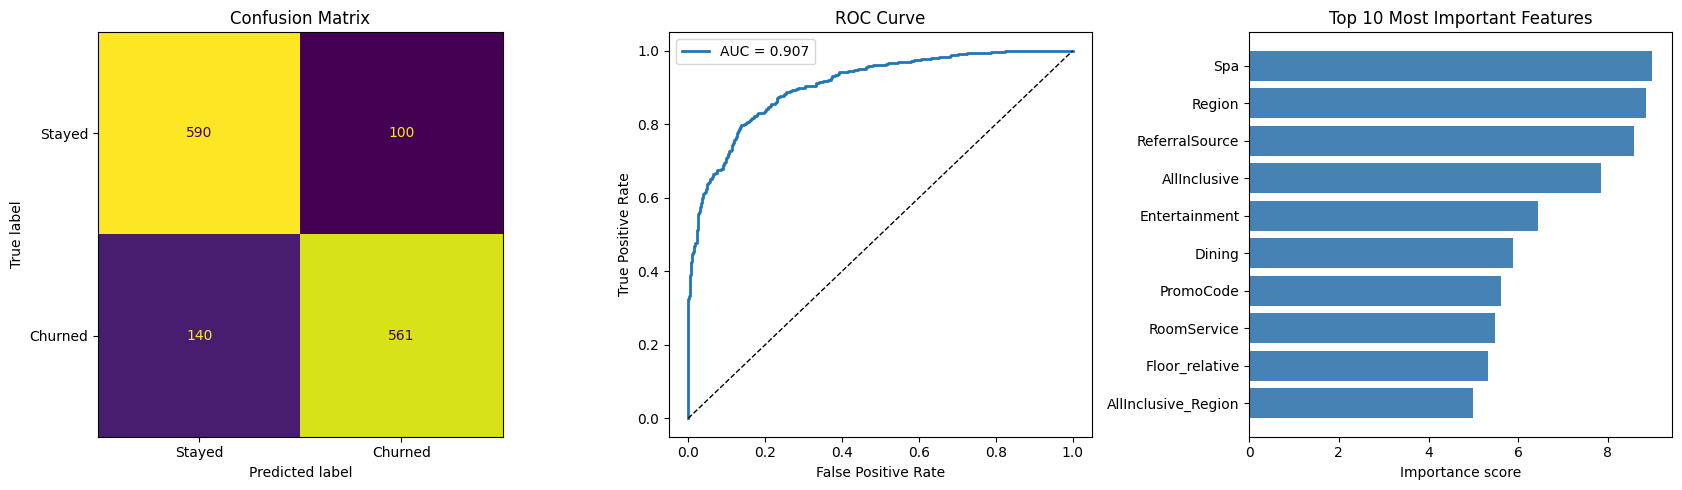

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix 
# Rows = actual, columns = predicted. We want the diagonal to be high.
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# Findings: 
# 1. 590 customers stayed and were correctly predicted as stayed, False Positives = 100
# 2. 561 customers churned and were correctly predicted as churned, False Negatives = 140
# These are used to calculate the F1 score and precision/recall


# ROC Curve 
# Does the model assign higher risk scores to churners than non-churners?
# AUC closer to 1.0 means the model ranks churners above non-churners more reliably. 
fpr, tpr, _ = roc_curve(y_val, probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Findings: 
# 1. AUC = 0.913 -> the model ranks churners above non-churners about 91% of the time.
# 2. Curve rises steeply near the left side -> high true positive rate while keeping false positives relatively low

# Feature Importance (gain, split)
# Which features did the model rely on the most? As in tree models, it is based on how much a feature helped split the data into better groups.
importances = pd.Series(
    eval_model.get_feature_importance(),
    index=FEATURE_COLS
).nlargest(10).sort_values()

axes[2].barh(importances.index, importances.values, color="steelblue")
axes[2].set_xlabel("Importance score")
axes[2].set_title("Top 10 Most Important Features")

plt.tight_layout()
plt.show()

# XGBoost vs CatBoost: More manual control (more parameters) -> more tuning
# CatBoost: Handles categorical features and missing values natively -> less preprocessing

## 9. Make Predictions

Now we retrain the tuned model on the **full** training set (all 6,954 guests) and predict on the test set.
The threshold is 0.50 — if the model gives a guest a probability above 50%, we predict churn.

In [ ]:
# Train on all available labeled data
final_model = CatBoostClassifier(
    **study.best_params,
    random_seed=RANDOM_STATE,
    verbose=0,
    cat_features=CAT_FEATURES,
    thread_count=-1
)
final_model.fit(X, y)

# Predict on the test set using the standard 0.50 threshold
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.50).astype(int)

# Build the submission file
submission = clean_test[[ID_COL]].copy()
submission[TARGET] = test_preds
submission.to_csv("submission.csv", index=False)

print(f"Saved submission.csv  ({len(submission)} rows)")
print(f"Predicted churn rate on test set: {submission[TARGET].mean():.1%}")
submission.head(10)

Saved submission.csv  (1739 rows)
Predicted churn rate on test set: 48.0%


,GuestID,Churned
0,154038,1
1,620160,0
2,655103,0
3,126993,0
4,635228,0
5,844514,0
6,541503,1
7,787572,1
8,645651,0
9,849608,1
